In [74]:
# Load important libraries
import numpy as np
import matplotlib.pyplot as plt

### Question 1

Part a
(RK4 Method)


In [75]:
# Basic Runge Kutta 4
def RK4(h,ti,tf,xi,f):
    N = int((tf - ti)/h)
    t = ti + h*np.arange(N+1)
    
    x = np.zeros((N+1,2)) #storing y and p values and updating them simulataneously through eulerformula

    x[0] = xi #initialising the first value

    for i in range(N):
        k1 = h * f(t[i], x[i]) #updating the y and p values accoriding to euler formula by coding up the 
        k2 = h * f(t[i] + h * 0.5, x[i] + k1 * 0.5)
        k3 = h * f(t[i] + h * 0.5, x[i] + k2 * 0.5)
        k4 = h * f(x[i] + h, x[i] + k3)
        
        x[i+1] = x[i] + (k1 + 2*k2+ 2*k3 + k4)/6
        
    #print(x)
    return x

In [76]:
# parameters
mu = 5.0
lam = 40.0

def f(t, Y):
    y, v = Y
    dydt = v
    dvdt = mu*(1 - y**2)*v - lam*y
    return np.array([dydt, dvdt])

# Step size h
h = 10e-4

# Time span 
t0 = 0.0
tT = 20.0

Y = [0.5,0.0]

Var = RK4(h,t0,tT,Y,f)
x_r = Var[:,0]
v_r = Var[:,1]
print(x_r)
print(v_r)


[ 0.5         0.49998999  0.4999599  ... -1.99245474 -1.99109426
 -1.98967474]
[ 0.         -0.02003741 -0.04014931 ...  1.33065861  1.39014598
  1.44874112]


### Plot the solution.

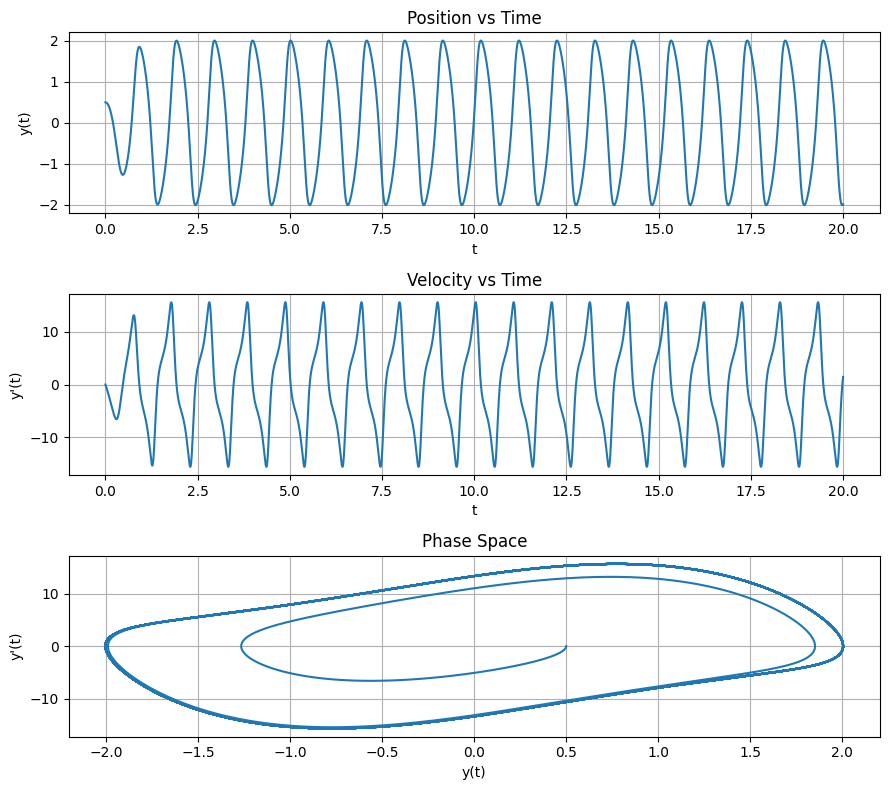

In [77]:
import matplotlib.pyplot as plt

N = int((tT - t0)/h)
t = t0 + h*np.arange(N+1)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(9, 8))

# Position vs time

axes[0].plot(t, x_r)
axes[0].set_title("Position vs Time")
axes[0].set_ylabel("y(t)")
axes[0].set_xlabel("t")
axes[0].grid()

# Velocity vs Time

axes[1].plot(t, v_r)
axes[1].set_title("Velocity vs Time")
axes[1].set_ylabel("y'(t)")
axes[1].set_xlabel("t")
axes[1].grid()

# Phase Space

axes[2].plot(x_r,v_r)
axes[2].set_title("Phase Space")
axes[2].set_xlabel("y(t)")
axes[2].set_ylabel("y'(t)")
axes[2].grid()

plt.tight_layout()
plt.show()


Part b)

In [78]:
# Dormand-Prince in matrix form
a = [0.2, 0.3, 0.8, 8/9, 1.0, 1.0]
b = [
    [1/5, 0, 0, 0, 0, 0],
    [3/40, 9/40, 0, 0, 0, 0],
    [44/45, -56/15, 32/9, 0, 0, 0],
    [19372/6561, -25360/2187, 64448/6561, -212/729, 0, 0],
    [9017/3168, -355/33, 46732/5247, 49/176, -5103/18656, 0],
    [35/384, 0, 500/1113, 125/192, -2187/6784, 11/84]
]
c = [35/384, 0, 500/1113, 125/192, -2187/6784, 11/84, 0]

# Dormand-Prince
a2 = 1/5;  b21 = 1/5
a3 = 3/10; b31 = 3/40;       b32 = 9/40
a4 = 4/5;  b41 = 44/45;      b42 = -56/15;      b43 = 32/9
a5 = 8/9;  b51 = 19372/6561; b52 = -25360/2187; b53 = 64448/6561; b54 =-212/729
a6 = 1;    b61 = 9017/3168;  b62 = -355/33;     b63 = 46732/5247; b64 = 49/176;  b65 = -5103/18656
a7 = 1;    b71 = 35/384;     b72 = 0;           b73 = 500/1113;   b74 = 125/192; b75 = -2187/6784;  b76 = 11/84

c1 = 35/384; c2 = 0; c3 = 500/1113; c4 = 125/192; c5=-2187/6784; c6 = 11/84; c7 = 0
c1s = 5179/57600; c2s = 0; c3s = 7571/16695; c4s = 393/640; c5s = -92097/339200; c6s = 187/2100; c7s = 1/40

### An implementation of 4th and 5th order embedded RK methods using Butcher tableau


In [79]:
# Embedded Runge-Kutta formulas
def erk54(f, x, y, h):
    k1 = h*f(x, y)
    k2 = h*f(x + a2*h, y + b21*k1)
    k3 = h*f(x + a3*h, y + b31*k1 + b32*k2)
    k4 = h*f(x + a4*h, y + b41*k1 + b42*k2 + b43*k3)
    k5 = h*f(x + a5*h, y + b51*k1 + b52*k2 + b53*k3 + b54*k4)
    k6 = h*f(x + a6*h, y + b61*k1 + b62*k2 + b63*k3 + b64*k4 + b65*k5)
    y5 = y + c1*k1 + c2*k2 + c3*k3 + c4*k4 + c5*k5 + c6*k6       
    k7 = h*f(x + a7*h, y5)
    y4 = y + c1s*k1 + c2s*k2 + c3s*k3 + c4s*k4 + c5s*k5 + c6s*k6 + c7s*k7
    return y5, y4

# A caller function
def caller5(my_method, fn, y_ini, x0, xT, h):
    # x values uniformly sampled
    N = int((xT - x0)/h)
    xs = x0 + h*np.arange(N+1)
   # number of points
    N = len(xs) 
    # Initialize
    y = np.asarray(y_ini)
    # Initialize storage
    ys = np.zeros((N, len(y_ini)))
    # Loop over all xs
    for i in range(N):
        # store and ...
        ys[i,:] = y
        x = xs[i]
        # ... update
        y, y4 = my_method(fn,x,y,h)
    return ys


def caller4(my_method, fn, y_ini, x0, xT, h):
    # x values uniformly sampled
    N = int((xT - x0)/h)
    xs = x0 + h*np.arange(N+1)
    # number of points
    N = len(xs) 
    # Initialize
    y = np.asarray(y_ini)
    # Initialize storage
    ys = np.zeros((N, len(y_ini)))
    # Loop over all xs
    for i in range(N):
        # store and ...
        ys[i,:] = y
        x = xs[i]
        # ... update
        y5, y = my_method(fn,x,y,h)
    return ys

In [80]:
# parameters
mu = 5.0
lam = 40.0

# Define the function
def f(t, Y):
    y, v = Y
    dydt = v
    dvdt = mu*(1 - y**2)*v - lam*y
    return np.array([dydt, dvdt])

# Initialize the parameters
max_iter = 500
abstol = 1.0e-6
reltol = 1.0e-8

# Step size h
h = 10e-4

# Time span 
t0 = 0.0
tT = 20.0

Y = [0.5,0.0]

# Caller functions provide the solutions
yserk5 = caller5(erk54, f, Y, t0, tT, h)
yserk4 = caller4(erk54, f, Y, t0, tT, h)

In [81]:
pos_yserk4 , vel_yserk4 = yserk4[:,0], yserk4[:,1]
pos_yserk5 , vel_yserk5 = yserk5[:,0], yserk5[:,1]
print(pos_yserk4, vel_yserk5)

[ 0.5         0.49998999  0.4999599  ... -1.99245473 -1.99109426
 -1.98967474] [ 0.         -0.02003741 -0.04014931 ...  1.33065874  1.39014611
  1.44874126]


### plot solutions and errors

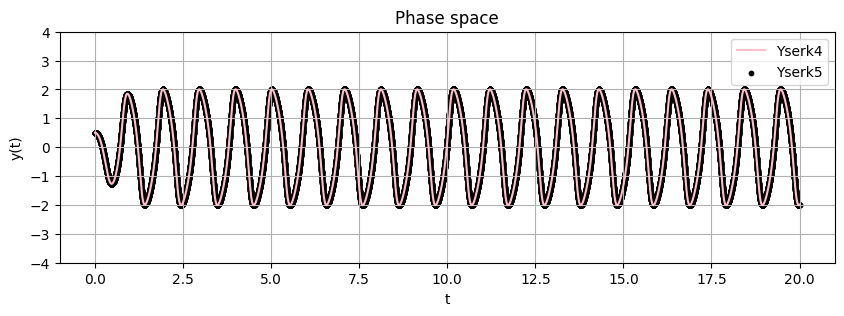

In [82]:
import matplotlib.pyplot as plt

N = int((tT - t0)/h)
t = t0 + h*np.arange(N+1)

plt.figure(figsize=(10,3))
plt.plot(t, pos_yserk4, label="Yserk4",color="pink")
plt.scatter(t, pos_yserk5, label="Yserk5", color = "black", s=10)
plt.xlabel("t")
plt.ylabel("y(t)")
plt.ylim(-4,4)
plt.title("Phase space")
plt.grid()
plt.legend()
plt.show()

In [83]:
# Predictor-Corrector
# Embedded Runge-Kutta formulas
def erk54h(f, x, y, h, k7bh):
    # Implement FSAL (first same as last)
    # The first
    # k1 = k7bh, unless k1 is zero (initially)
    if sum(k7bh)==0: 
        k1 = h*f(x, y)
    else:
        k1 = k7bh*h

    # Implement rest of the Butcher table
    k2 = h*f(x + a2*h, y + b21*k1)
    k3 = h*f(x + a3*h, y + b31*k1 + b32*k2)
    k4 = h*f(x + a4*h, y + b41*k1 + b42*k2 + b43*k3)
    k5 = h*f(x + a5*h, y + b51*k1 + b52*k2 + b53*k3 + b54*k4)
    k6 = h*f(x + a6*h, y + b61*k1 + b62*k2 + b63*k3 + b64*k4 + b65*k5)

    # get y fifth-order correct
    y5 = y + c1*k1 + c2*k2 + c3*k3 + c4*k4 + c5*k5 + c6*k6 # c7 = 0     
    
    # FSAL -> the last
    k7bh = f(x + a7*h, y5)

    #@printf("%.6f %.6f %.6f %.6f\n",x, y[1], y5[1], k7bh[1])

    # get y fourth-order correct
    y4 = y + c1s*k1 + c2s*k2 + c3s*k3 + c4s*k4 + c5s*k5 + c6s*k6 + c7s*k7bh*h

    # return y, error, k7bh
    err = abs(y5 - y4)
    return y5, err, k7bh

def caller54(fn, y_ini, x0, xT, h0, max_iter, abstol, reltol):
    y = np.asarray(y_ini); h = h0;
    ys = np.zeros((max_iter, len(y_ini)))
    xs = np.zeros((max_iter, 1))
    xs[0] = x0; ys[0,:] = y
    x = x0; i = 0; k = 1
    k7bh = np.zeros(len(y_ini))
    while x<=xT and i<max_iter:

        # get the next y and the error
        ytrial, err, k7new = erk54h(fn, x, y, h, k7bh)

        # get max error and the scale factor
        scale = abstol + reltol*np.abs(y)
        merr = np.max(err / scale)

        #scale_factor = (tol/merr)^0.2
        
        # for debugging
        #print("%2d %.4f %.6f %.6f %g"%(i,xs[i],ys[i],h,merr))
        
        if merr == 0.0: 
            merr = 1e-16

        hnew = 0.9*h*(merr)**(-0.2)
        
        # If the step is valid (less error than tol)
        # then we proceed
        if merr<= 1.0:   

            x += h
            i += 1
            y = ytrial
            k7bh = k7new
            xs[i] = x
            ys[i,:] = y

            #k7 = k7t
            #print("%2d %.4f %.6f %.6f"%(i,xs[i],ys[i],k7[1]))
        
        # anyway we update h every time
        h = hnew
    
    # if the maximum number of steps exceeded
    if i>=max_iter:
        print(i," Increase max_iter.")
        return None
    
    # return the usable portion of the array
    return xs[1:i-1], ys[1:i-1,:]


In [84]:
# parameters
mu = 5.0
lam = 40.0

# Define the function
def f(t, Y):
    y, v = Y
    dydt = v
    dvdt = mu*(1 - y**2)*v - lam*y
    return np.array([dydt, dvdt])

# Initialize the parameters
max_iter = 2000
abstol = 1.0e-6
reltol = 1.0e-8

# Step size h
h = 10e-4

# Time span 
t0 = 0.0
tT = 20.0

Y = [0.5,0.0]

# Final call 
xs54, yserk54 = caller54(f, Y, t0, tT, h, max_iter, abstol, reltol)


In [85]:
print("TOTAL NUMBER OF STEPS REQUIRED:")
print(len((xs54)))
print("==========================================================================")
y_vals = yserk54[:,0]
v_vals = yserk54[:,1]
print(y_vals,v_vals)

TOTAL NUMBER OF STEPS REQUIRED:
1255
[ 0.49998999  0.47831389  0.41508056 ... -1.9799026  -2.00015234
 -2.00573024] [-0.02003741 -0.97738669 -1.9992977  ... -2.29531779 -1.00821105
  0.10033149]


Part c)

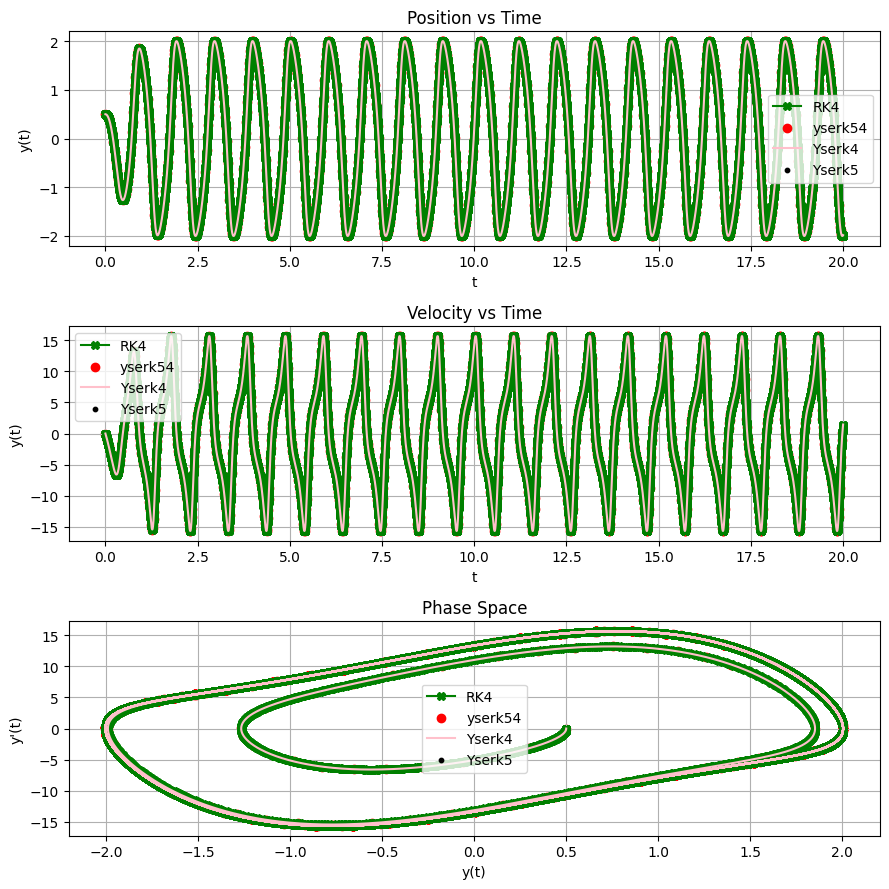

In [86]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(9, 9))

# Position vs Time
axes[0].plot(t, x_r, marker="X",color="green",label = "RK4")
axes[0].scatter(xs54, yserk54[:,0],label="yserk54",color="red")
axes[0].plot(t, pos_yserk4, label="Yserk4",color="pink")
axes[0].scatter(t, pos_yserk5, label="Yserk5", color = "black", s=10)
axes[0].set_title("Position vs Time")
axes[0].set_ylabel("y(t)")
axes[0].set_xlabel("t")
axes[0].legend()
axes[0].grid()

# Velocity vs Time
axes[1].plot(t, v_r, marker="X",color="green",label = "RK4")
axes[1].scatter(xs54, yserk54[:,1],label="yserk54",color="red")
axes[1].plot(t, vel_yserk4, label="Yserk4",color="pink")
axes[1].scatter(t, vel_yserk5, label="Yserk5", color = "black", s=10)
axes[1].set_title("Velocity vs Time")
axes[1].set_ylabel("y(t)")
axes[1].set_xlabel("t")
axes[1].legend()
axes[1].grid()


# Phase Space

axes[2].plot(x_r, v_r, marker="X",color="green",label = "RK4")
axes[2].scatter(yserk54[:,0], yserk54[:,1],label="yserk54",color="red")
axes[2].plot(pos_yserk4, vel_yserk4, label="Yserk4",color="pink")
axes[2].scatter(pos_yserk5, vel_yserk5, label="Yserk5", color = "black", s=10)
axes[2].set_title("Phase Space")
axes[2].set_ylabel("y'(t)")
axes[2].set_xlabel("y(t)")
axes[2].legend()
axes[2].grid()


plt.tight_layout()
plt.show()



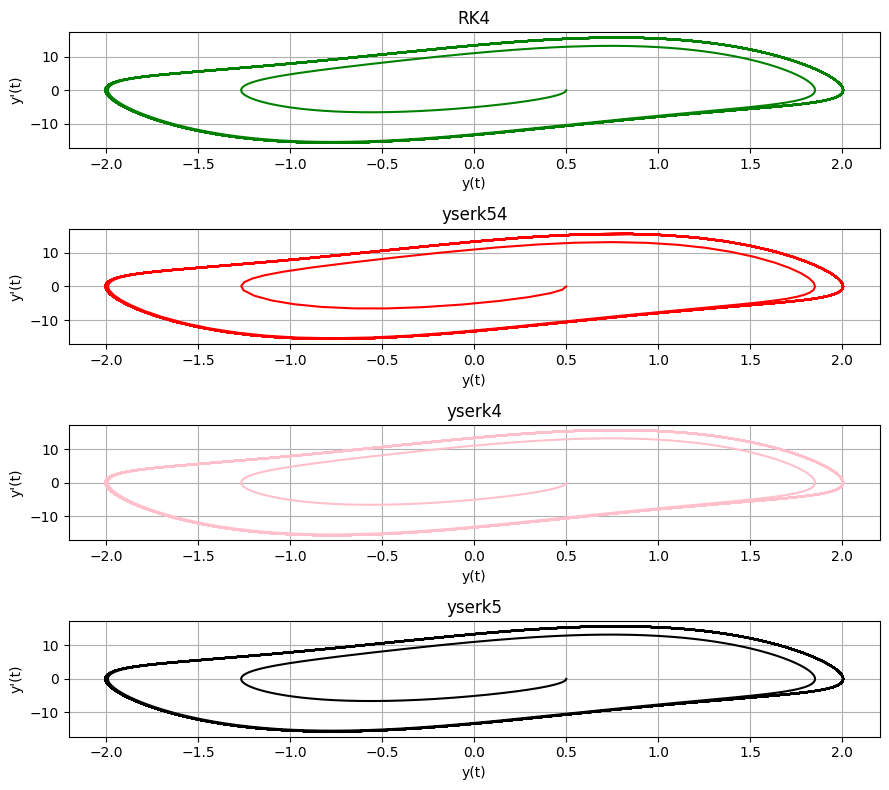

In [87]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(9, 8))

# RK4
axes[0].plot(x_r, v_r,color="green",label = "RK4")
axes[0].set_title("RK4")
axes[0].set_ylabel("y'(t)")
axes[0].set_xlabel("y(t)")
axes[0].grid()

# yserk54

axes[1].plot(yserk54[:,0], yserk54[:,1],label="yserk54",color="red")
axes[1].set_title("yserk54")
axes[1].set_ylabel("y'(t)")
axes[1].set_xlabel("y(t)")
axes[1].grid()

# yserk4

axes[2].plot(pos_yserk4, vel_yserk4, label="Yserk4",color="pink")
axes[2].set_title("yserk4")
axes[2].set_xlabel("y(t)")
axes[2].set_ylabel("y'(t)")
axes[2].grid()

#yserk5

axes[3].plot(pos_yserk5, vel_yserk5, label="Yserk5", color = "black")
axes[3].set_title("yserk5")
axes[3].set_xlabel("y(t)")
axes[3].set_ylabel("y'(t)")
axes[3].grid()

plt.tight_layout()
plt.show()



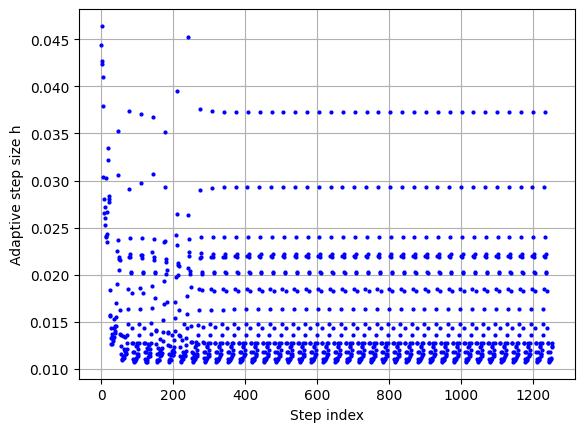

In [88]:
xs54l = [xs54[i][0] for i in range(len(xs54))]
plt.plot(np.diff(xs54l),'bo',markersize=2)
plt.xlabel('Serial number')
plt.ylabel('h values')
plt.xlabel("Step index")
plt.ylabel("Adaptive step size h")
plt.grid(True)
